# SpaceCode PS-0.3: Asteroid Hazard Classification

**Objective**: Build a binary classifier to predict whether an asteroid is hazardous using orbital and physical features.

**Focus**: Imbalanced classification, physics-based baseline, high recall optimization

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, recall_score, precision_score, f1_score
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 1: Load Data and Drop Non-Feature Columns

In [3]:
# Load the dataset
df = pd.read_csv('nasa_neows_1950_2025.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nFirst few rows:")
df.head()

Dataset shape: (375659, 41)

Column names:
['Date', 'Neo Reference ID', 'Name', 'Absolute Magnitude', 'Est Dia in KM(min)', 'Est Dia in KM(max)', 'Est Dia in M(min)', 'Est Dia in M(max)', 'Est Dia in Miles(min)', 'Est Dia in Miles(max)', 'Est Dia in Feet(min)', 'Est Dia in Feet(max)', 'Close Approach Date', 'Epoch Date Close Approach', 'Relative Velocity km per sec', 'Relative Velocity km per hr', 'Miles per hour', 'Miss Dist.(Astronomical)', 'Miss Dist.(lunar)', 'Miss Dist.(kilometers)', 'Miss Dist.(miles)', 'Orbiting Body', 'Orbit ID', 'Orbit Determination Date', 'Orbit Uncertainty', 'Minimum Orbit Intersection', 'Jupiter Tisserand Invariant', 'Epoch Osculation', 'Eccentricity', 'Semi Major Axis', 'Inclination', 'Asc Node Longitude', 'Orbital Period', 'Perihelion Distance', 'Perihelion Arg', 'Aphelion Dist', 'Perihelion Time', 'Mean Anomaly', 'Mean Motion', 'Equinox', 'Hazardous']

First few rows:


,Date,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),...,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Equinox,Hazardous
0,1900-01-01,3102683.0,(2001 XX4),22.10,0.101054,0.225964,101.054342,225.964377,0.062792,0.140408,...,127.074771,368.799662,0.446121,186.829730,1.566791,2.460307e+06,255.653949,0.976140,J2000,True
1,1900-01-01,3285299.0,(2005 OE3),20.30,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,...,321.032500,716.317846,0.895238,58.408586,2.238299,2.460091e+06,55.020372,0.502570,J2000,True
2,1900-01-01,3653973.0,(2013 WU45),20.37,0.224158,0.501233,224.158379,501.233372,0.139286,0.311452,...,36.158624,621.104718,0.585125,153.791066,2.264194,2.460421e+06,231.962485,0.579612,J2000,False
3,1900-01-01,3703077.0,(2014 YT34),24.70,0.030518,0.068240,30.517923,68.240151,0.018963,0.042402,...,285.381728,442.772170,0.955427,240.118639,1.318368,2.460183e+06,13.910335,0.813059,J2000,False
4,1900-01-01,3771605.0,(2017 EE23),21.80,0.116026,0.259442,116.025908,259.441818,0.072095,0.161210,...,149.163448,299.267765,0.542113,244.187323,1.209095,2.460128e+06,87.787093,1.202936,J2000,False


In [17]:
# Identify columns to drop (name, id, designation, date columns)
columns_to_drop = []
for col in df.columns:
    col_lower = col.lower()
    if any(keyword in col_lower for keyword in ['name', 'id', 'designation', 'date', 'time', 'close_approach']):
        columns_to_drop.append(col)

print(f"Columns to drop: {columns_to_drop}")

# Drop non-feature columns
df_clean = df.drop(columns=columns_to_drop, errors='ignore')

# Normalize target to a clean 0/1 integer column
if 'Hazardous' not in df_clean.columns:
    raise KeyError("Expected target column 'Hazardous' not found after dropping columns.")

# Drop rows with missing target (cannot be used for supervised learning)
missing_target = int(df_clean['Hazardous'].isna().sum())
if missing_target > 0:
    print(f"Dropping {missing_target} rows with missing 'Hazardous' labels")
    df_clean = df_clean.dropna(subset=['Hazardous']).copy()

def to_binary_hazardous(s: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(s):
        return s.astype(int)
    if pd.api.types.is_numeric_dtype(s):
        # If already {0,1} keep as is; otherwise coerce >0 to 1
        unique = set(pd.Series(s.dropna().unique()).tolist())
        if unique.issubset({0, 1}):
            return s.astype(int)
        return (pd.to_numeric(s, errors='coerce').fillna(0) > 0).astype(int)
    s_nonnull = s.dropna()
    mapped = (
        s_nonnull.astype(str)
        .str.strip()
        .str.lower()
        .map({
            'true': 1, 'false': 0,
            't': 1, 'f': 0,
            '1': 1, '0': 0,
            'yes': 1, 'no': 0,
            'y': 1, 'n': 0,
        })
    )
    if mapped.isna().any():
        bad = sorted(set(s_nonnull[mapped.isna()].astype(str).unique().tolist()))[:10]
        raise ValueError(f"Unrecognized values in 'Hazardous': {bad}")
    out = pd.Series(index=s.index, dtype='float')
    out.loc[mapped.index] = mapped.astype(int)
    return out.astype(int)

df_clean['Hazardous'] = to_binary_hazardous(df_clean['Hazardous'])

print(f"\nDataset shape after dropping columns: {df_clean.shape}")
print(f"\nRemaining columns:")
print(df_clean.columns.tolist())
print(f"\nHazardous dtype after normalization: {df_clean['Hazardous'].dtype}")
print(f"Hazardous unique values: {sorted(df_clean['Hazardous'].unique().tolist())}")

Columns to drop: ['Date', 'Neo Reference ID', 'Name', 'Close Approach Date', 'Epoch Date Close Approach', 'Orbit ID', 'Orbit Determination Date', 'Perihelion Time']
Dropping 420 rows with missing 'Hazardous' labels

Dataset shape after dropping columns: (375239, 33)

Remaining columns:
['Absolute Magnitude', 'Est Dia in KM(min)', 'Est Dia in KM(max)', 'Est Dia in M(min)', 'Est Dia in M(max)', 'Est Dia in Miles(min)', 'Est Dia in Miles(max)', 'Est Dia in Feet(min)', 'Est Dia in Feet(max)', 'Relative Velocity km per sec', 'Relative Velocity km per hr', 'Miles per hour', 'Miss Dist.(Astronomical)', 'Miss Dist.(lunar)', 'Miss Dist.(kilometers)', 'Miss Dist.(miles)', 'Orbiting Body', 'Orbit Uncertainty', 'Minimum Orbit Intersection', 'Jupiter Tisserand Invariant', 'Epoch Osculation', 'Eccentricity', 'Semi Major Axis', 'Inclination', 'Asc Node Longitude', 'Orbital Period', 'Perihelion Distance', 'Perihelion Arg', 'Aphelion Dist', 'Mean Anomaly', 'Mean Motion', 'Equinox', 'Hazardous']

Hazard

Target variable distribution (0=Non-hazardous, 1=Hazardous):
Hazardous
0    327055
1     48184
Name: count, dtype: int64

Class imbalance ratio (neg:pos): 6.79:1


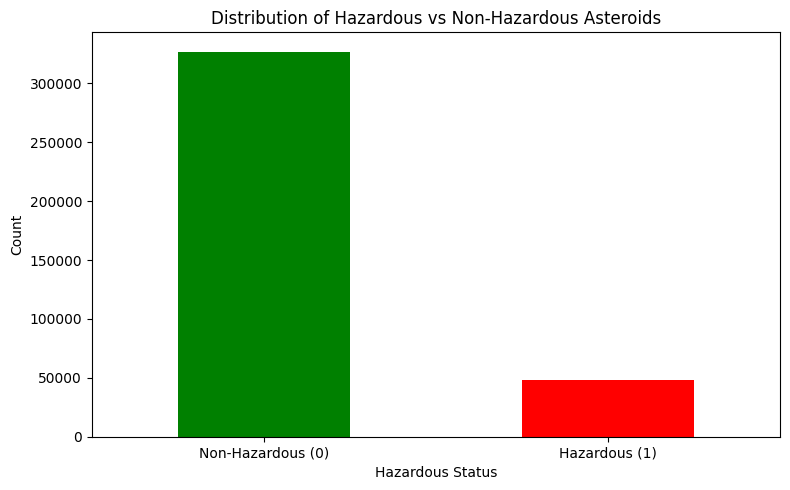

In [18]:
# Check target variable distribution
print("Target variable distribution (0=Non-hazardous, 1=Hazardous):")
counts = df_clean['Hazardous'].value_counts().sort_index()
print(counts)

neg = int(counts.get(0, 0))
pos = int(counts.get(1, 0))
if pos == 0:
    raise ValueError("No positive (hazardous) samples found after target normalization.")
print(f"\nClass imbalance ratio (neg:pos): {neg / pos:.2f}:1")

# Visualize class distribution
plt.figure(figsize=(8, 5))
ax = counts.plot(kind='bar', color=['green', 'red'])
plt.title('Distribution of Hazardous vs Non-Hazardous Asteroids')
plt.xlabel('Hazardous Status')
plt.ylabel('Count')
plt.xticks([0, 1], ['Non-Hazardous (0)', 'Hazardous (1)'], rotation=0)
plt.tight_layout()
plt.show()

## Step 2: Physics-Based Baseline

Create a baseline using physical criteria:
- MOID (Minimum Orbit Intersection Distance) ≤ 0.05 AU
- Absolute Magnitude (H) ≤ 22 (brighter/larger objects)

Looking for MOID and absolute magnitude columns...
MOID column: Minimum Orbit Intersection
Magnitude column: Absolute Magnitude

=== Physics-Based Baseline Performance ===
Accuracy:  0.9976
Precision: 0.9943
Recall:    0.9868
F1-Score:  0.9905


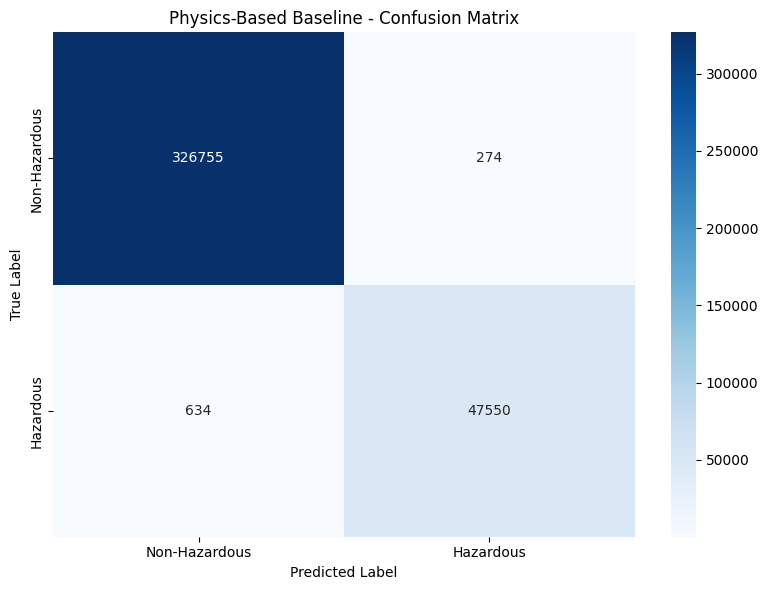

In [19]:
# Check for relevant physics columns
print("Looking for MOID and absolute magnitude columns...")

# Use exact column names from the dataset
moid_col = 'Minimum Orbit Intersection'
mag_col = 'Absolute Magnitude'

print(f"MOID column: {moid_col}")
print(f"Magnitude column: {mag_col}")

# Create physics-based prediction
if moid_col in df_clean.columns and mag_col in df_clean.columns:
    df_clean['hazard_phys'] = ((df_clean[moid_col] <= 0.05) & (df_clean[mag_col] <= 22)).astype(int)

    # Compare with actual labels
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    # Handle NaN values in physics baseline
    valid_mask = df_clean[[moid_col, mag_col]].notna().all(axis=1)

    y_true_phys = df_clean.loc[valid_mask, 'Hazardous'].astype(int)
    y_pred_phys = df_clean.loc[valid_mask, 'hazard_phys'].astype(int)

    accuracy = accuracy_score(y_true_phys, y_pred_phys)
    precision = precision_score(y_true_phys, y_pred_phys, zero_division=0)
    recall = recall_score(y_true_phys, y_pred_phys, zero_division=0)
    f1 = f1_score(y_true_phys, y_pred_phys, zero_division=0)

    print("\n=== Physics-Based Baseline Performance ===")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    # Confusion matrix (force 2x2)
    cm = confusion_matrix(y_true_phys, y_pred_phys, labels=[0, 1])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Hazardous', 'Hazardous'],
                yticklabels=['Non-Hazardous', 'Hazardous'])
    plt.title('Physics-Based Baseline - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
else:
    print("Warning: Could not find required columns. Looking for:")
    print(f"  - {moid_col}")
    print(f"  - {mag_col}")
    print(f"Available columns: {df_clean.columns.tolist()}")

# Drop the physics baseline column
if 'hazard_phys' in df_clean.columns:
    df_clean = df_clean.drop(columns=['hazard_phys'])

## Step 3: Handle Missing Values with Median Imputation

In [20]:
# Check missing values
missing_summary = df_clean.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

if len(missing_summary) > 0:
    print("Missing values per column:")
    print(missing_summary)
    print(f"\nMissing value percentages:")
    print((missing_summary / len(df_clean) * 100).round(2))
else:
    print("No missing values found!")

Missing values per column:
Orbiting Body                   75
Miss Dist.(Astronomical)        75
Miss Dist.(miles)               75
Miss Dist.(kilometers)          75
Miss Dist.(lunar)               75
Relative Velocity km per hr     75
Miles per hour                  75
Relative Velocity km per sec    75
Absolute Magnitude              26
Est Dia in Feet(max)            26
Est Dia in Feet(min)            26
Est Dia in Miles(max)           26
Est Dia in Miles(min)           26
Est Dia in M(max)               26
Est Dia in M(min)               26
Est Dia in KM(max)              26
Est Dia in KM(min)              26
dtype: int64

Missing value percentages:
Orbiting Body                   0.02
Miss Dist.(Astronomical)        0.02
Miss Dist.(miles)               0.02
Miss Dist.(kilometers)          0.02
Miss Dist.(lunar)               0.02
Relative Velocity km per hr     0.02
Miles per hour                  0.02
Relative Velocity km per sec    0.02
Absolute Magnitude              0.01
Est 

In [21]:
# Separate features and target
X = df_clean.drop(columns=['Hazardous'])
y = df_clean['Hazardous'].astype(int)

# Keep only numerical columns
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X = X[numerical_cols]

print(f"Number of numerical features: {len(numerical_cols)}")
print(f"Feature names: {numerical_cols}")

# Median imputation for missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

print(f"\nMissing values after imputation: {X_imputed.isnull().sum().sum()}")

Number of numerical features: 30
Feature names: ['Absolute Magnitude', 'Est Dia in KM(min)', 'Est Dia in KM(max)', 'Est Dia in M(min)', 'Est Dia in M(max)', 'Est Dia in Miles(min)', 'Est Dia in Miles(max)', 'Est Dia in Feet(min)', 'Est Dia in Feet(max)', 'Relative Velocity km per sec', 'Relative Velocity km per hr', 'Miles per hour', 'Miss Dist.(Astronomical)', 'Miss Dist.(lunar)', 'Miss Dist.(kilometers)', 'Miss Dist.(miles)', 'Orbit Uncertainty', 'Minimum Orbit Intersection', 'Jupiter Tisserand Invariant', 'Epoch Osculation', 'Eccentricity', 'Semi Major Axis', 'Inclination', 'Asc Node Longitude', 'Orbital Period', 'Perihelion Distance', 'Perihelion Arg', 'Aphelion Dist', 'Mean Anomaly', 'Mean Motion']

Missing values after imputation: 0


## Step 4: Log-Transform Skewed Features

In [22]:
# Identify diameter and velocity columns
diameter_cols = [col for col in X_imputed.columns if 'dia' in col.lower() and 'km' in col.lower()]
velocity_cols = [col for col in X_imputed.columns if 'velocity' in col.lower()]

print(f"Diameter columns: {diameter_cols}")
print(f"Velocity columns: {velocity_cols}")

# Columns to log-transform
log_transform_cols = diameter_cols + velocity_cols

# Apply log transformation (add small constant to avoid log(0))
X_transformed = X_imputed.copy()
for col in log_transform_cols:
    if col in X_transformed.columns:
        # Add 1e-10 to avoid log(0)
        X_transformed[col] = np.log1p(X_transformed[col])
        print(f"Log-transformed: {col}")

Diameter columns: ['Est Dia in KM(min)', 'Est Dia in KM(max)']
Velocity columns: ['Relative Velocity km per sec', 'Relative Velocity km per hr']
Log-transformed: Est Dia in KM(min)
Log-transformed: Est Dia in KM(max)
Log-transformed: Relative Velocity km per sec
Log-transformed: Relative Velocity km per hr


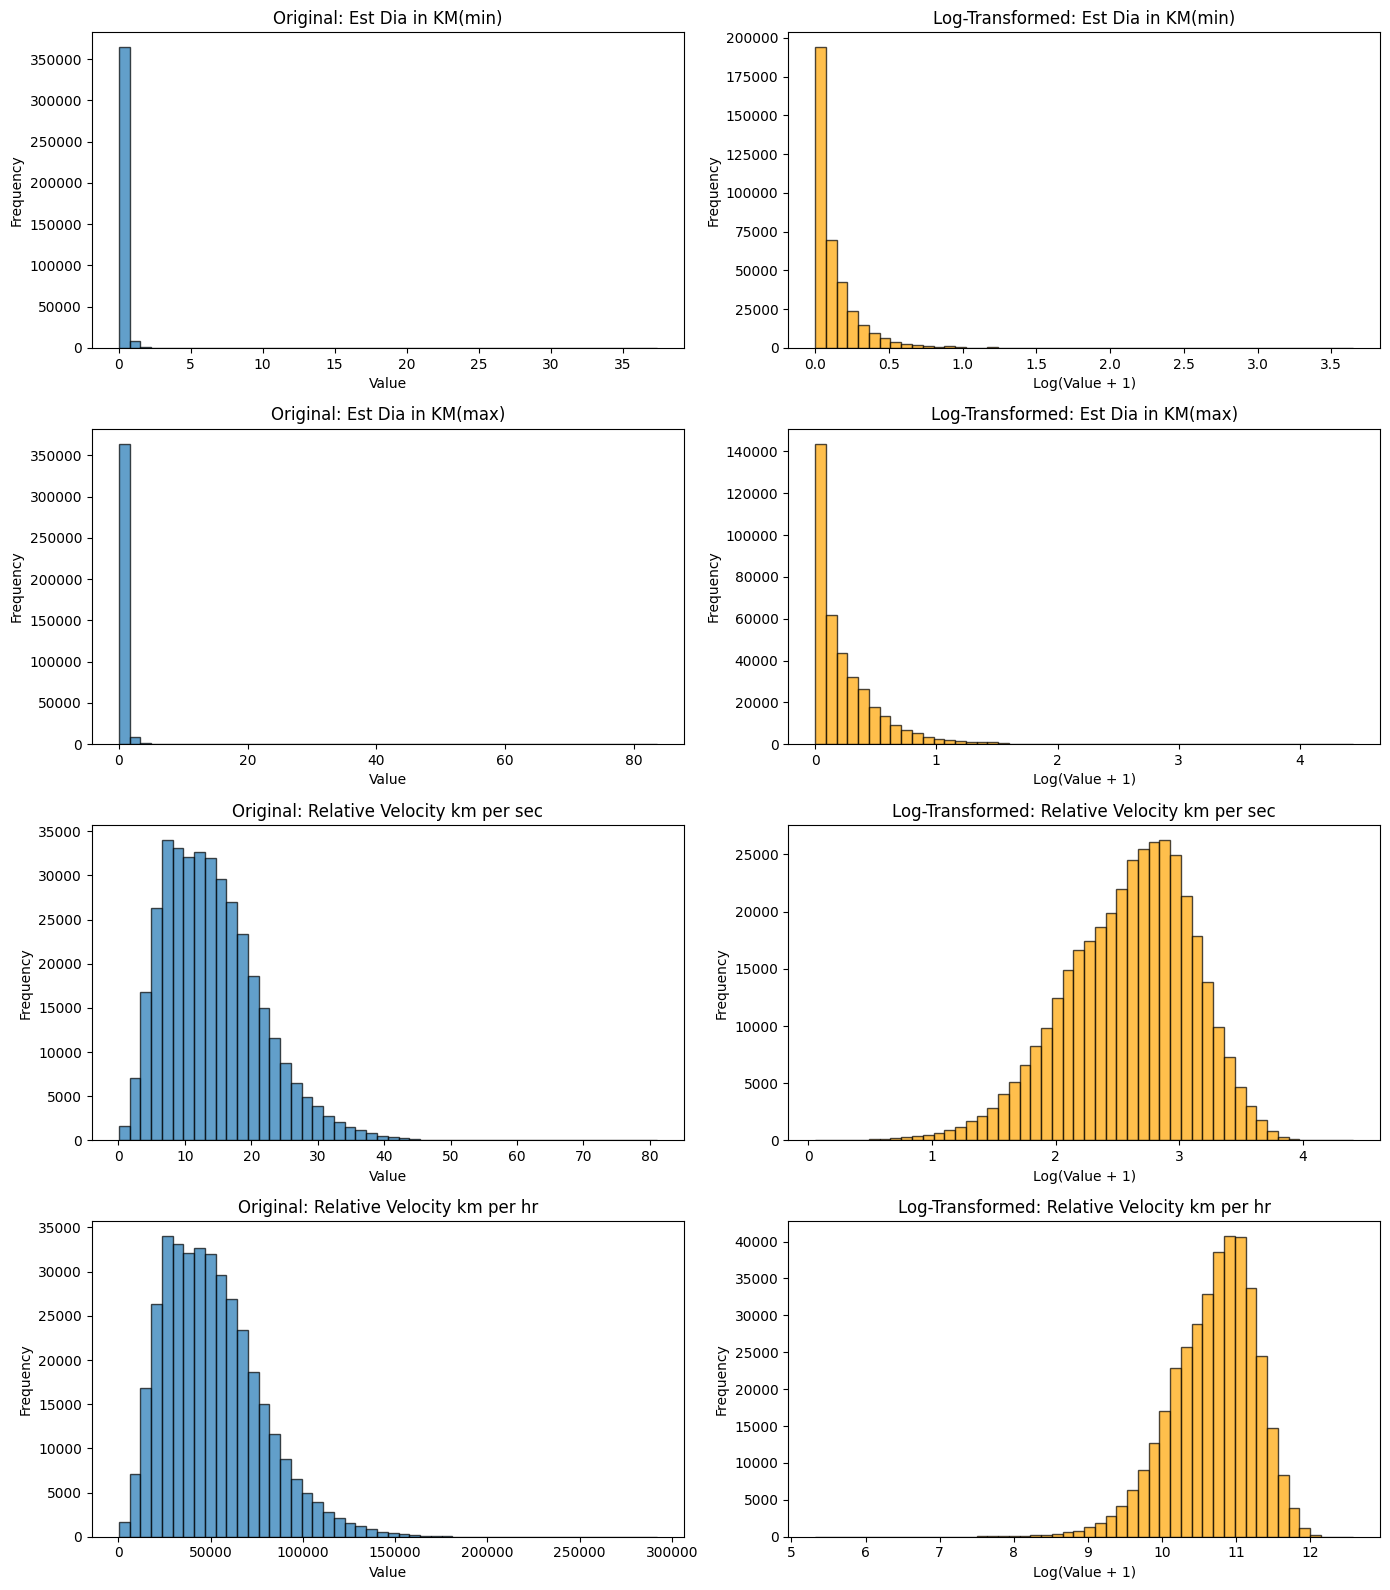

In [23]:
# Visualize distributions before and after transformation
if log_transform_cols:
    fig, axes = plt.subplots(len(log_transform_cols), 2, figsize=(14, 4*len(log_transform_cols)))
    if len(log_transform_cols) == 1:
        axes = axes.reshape(1, -1)
    
    for idx, col in enumerate(log_transform_cols):
        if col in X_imputed.columns:
            # Original distribution
            axes[idx, 0].hist(X_imputed[col], bins=50, edgecolor='black', alpha=0.7)
            axes[idx, 0].set_title(f'Original: {col}')
            axes[idx, 0].set_xlabel('Value')
            axes[idx, 0].set_ylabel('Frequency')
            
            # Log-transformed distribution
            axes[idx, 1].hist(X_transformed[col], bins=50, edgecolor='black', alpha=0.7, color='orange')
            axes[idx, 1].set_title(f'Log-Transformed: {col}')
            axes[idx, 1].set_xlabel('Log(Value + 1)')
            axes[idx, 1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

## Step 5: Standardize Features

In [24]:
# Standardization (z-score normalization)
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_transformed), 
    columns=X_transformed.columns, 
    index=X_transformed.index
)

print("Features standardized successfully!")
print(f"\nFeature statistics after standardization:")
print(X_scaled.describe().round(3))

Features standardized successfully!

Feature statistics after standardization:
       Absolute Magnitude  Est Dia in KM(min)  Est Dia in KM(max)  \
count          375239.000          375239.000          375239.000   
mean               -0.000              -0.000              -0.000   
std                 1.000               1.000               1.000   
min                -4.631              -0.763              -0.870   
25%                -0.759              -0.627              -0.693   
50%                -0.027              -0.369              -0.370   
75%                 0.756               0.256               0.355   
max                 3.578              20.671              14.543   

       Est Dia in M(min)  Est Dia in M(max)  Est Dia in Miles(min)  \
count         375239.000         375239.000             375239.000   
mean              -0.000              0.000                  0.000   
std                1.000              1.000                  1.000   
min               -

## Step 6: Stratified Train/Test Split (80/20)

In [25]:
# Stratified split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=RANDOM_STATE
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Training set size: 300191
Test set size: 75048

Training set class distribution:
Hazardous
0    261644
1     38547
Name: count, dtype: int64

Test set class distribution:
Hazardous
0    65411
1     9637
Name: count, dtype: int64


## Step 7: Train Models with Class Balancing

We'll train both XGBoost and LightGBM models with different strategies:
1. Using class weights
2. Using SMOTE for oversampling

In [26]:
# Calculate scale_pos_weight for imbalanced data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale pos weight: {scale_pos_weight:.2f}")

Scale pos weight: 6.79


### Model 1: XGBoost with Class Weights

In [27]:
# XGBoost with class weights
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    early_stopping_rounds=20
)

print("Training XGBoost with class weights...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("\n=== XGBoost with Class Weights ===")
print(classification_report(y_test, y_pred_xgb, target_names=['Non-Hazardous', 'Hazardous']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

Training XGBoost with class weights...

=== XGBoost with Class Weights ===
               precision    recall  f1-score   support

Non-Hazardous       1.00      1.00      1.00     65411
    Hazardous       1.00      1.00      1.00      9637

     accuracy                           1.00     75048
    macro avg       1.00      1.00      1.00     75048
 weighted avg       1.00      1.00      1.00     75048

ROC-AUC Score: 1.0000


### Model 2: LightGBM with Class Weights

In [28]:
# LightGBM with class weights
lgb_model = lgb.LGBMClassifier(
    class_weight='balanced',
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    verbose=-1
)

print("Training LightGBM with class weights...")
lgb_model.fit(X_train, y_train)

# Predictions
y_pred_lgb = lgb_model.predict(X_test)
y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("\n=== LightGBM with Class Weights ===")
print(classification_report(y_test, y_pred_lgb, target_names=['Non-Hazardous', 'Hazardous']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_lgb):.4f}")

Training LightGBM with class weights...

=== LightGBM with Class Weights ===
               precision    recall  f1-score   support

Non-Hazardous       1.00      1.00      1.00     65411
    Hazardous       1.00      1.00      1.00      9637

     accuracy                           1.00     75048
    macro avg       1.00      1.00      1.00     75048
 weighted avg       1.00      1.00      1.00     75048

ROC-AUC Score: 1.0000


### Model 3: XGBoost with SMOTE

In [29]:
# Apply SMOTE to training data
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Training set size after SMOTE: {len(X_train_smote)}")
print(f"Class distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# XGBoost with SMOTE
xgb_smote_model = xgb.XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

print("\nTraining XGBoost with SMOTE...")
xgb_smote_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_xgb_smote = xgb_smote_model.predict(X_test)
y_pred_proba_xgb_smote = xgb_smote_model.predict_proba(X_test)[:, 1]

# Evaluation
print("\n=== XGBoost with SMOTE ===")
print(classification_report(y_test, y_pred_xgb_smote, target_names=['Non-Hazardous', 'Hazardous']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_xgb_smote):.4f}")

Training set size after SMOTE: 523288
Class distribution after SMOTE:
Hazardous
0    261644
1    261644
Name: count, dtype: int64

Training XGBoost with SMOTE...

=== XGBoost with SMOTE ===
               precision    recall  f1-score   support

Non-Hazardous       1.00      1.00      1.00     65411
    Hazardous       1.00      1.00      1.00      9637

     accuracy                           1.00     75048
    macro avg       1.00      1.00      1.00     75048
 weighted avg       1.00      1.00      1.00     75048

ROC-AUC Score: 1.0000


## Step 8 & 9: Optimize for Recall and Tune Probability Threshold

Goal: Achieve ≥95% recall by adjusting the probability threshold

In [30]:
# Select best model based on ROC-AUC
models = {
    'XGBoost (Class Weights)': (xgb_model, y_pred_proba_xgb),
    'LightGBM (Class Weights)': (lgb_model, y_pred_proba_lgb),
    'XGBoost (SMOTE)': (xgb_smote_model, y_pred_proba_xgb_smote)
}

best_model_name = None
best_auc = 0
best_proba = None

for name, (model, proba) in models.items():
    auc = roc_auc_score(y_test, proba)
    if auc > best_auc:
        best_auc = auc
        best_model_name = name
        best_model = model
        best_proba = proba

print(f"Best model: {best_model_name}")
print(f"Best ROC-AUC: {best_auc:.4f}")

Best model: XGBoost (SMOTE)
Best ROC-AUC: 1.0000


In [31]:
# Find optimal threshold for ≥95% recall
thresholds = np.arange(0.01, 1.0, 0.01)
recalls = []
precisions = []
f1_scores = []

for threshold in thresholds:
    y_pred_threshold = (best_proba >= threshold).astype(int)
    recalls.append(recall_score(y_test, y_pred_threshold))
    precisions.append(precision_score(y_test, y_pred_threshold, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred_threshold, zero_division=0))

# Find threshold that achieves ≥95% recall
target_recall = 0.95
valid_thresholds = [(t, r, p, f) for t, r, p, f in zip(thresholds, recalls, precisions, f1_scores) if r >= target_recall]

if valid_thresholds:
    # Choose threshold with best F1-score among those achieving ≥95% recall
    optimal_threshold = max(valid_thresholds, key=lambda x: x[3])[0]
else:
    # If ≥95% recall not achievable, find threshold with maximum recall
    max_recall_idx = np.argmax(recalls)
    optimal_threshold = thresholds[max_recall_idx]
    print(f"Warning: Could not achieve {target_recall*100}% recall. Using threshold with maximum recall.")

print(f"\nOptimal threshold: {optimal_threshold:.3f}")

# Apply optimal threshold
y_pred_optimal = (best_proba >= optimal_threshold).astype(int)

print("\n=== Performance with Optimal Threshold ===")
print(classification_report(y_test, y_pred_optimal, target_names=['Non-Hazardous', 'Hazardous']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, best_proba):.4f}")


Optimal threshold: 0.530

=== Performance with Optimal Threshold ===
               precision    recall  f1-score   support

Non-Hazardous       1.00      1.00      1.00     65411
    Hazardous       1.00      1.00      1.00      9637

     accuracy                           1.00     75048
    macro avg       1.00      1.00      1.00     75048
 weighted avg       1.00      1.00      1.00     75048

ROC-AUC Score: 1.0000


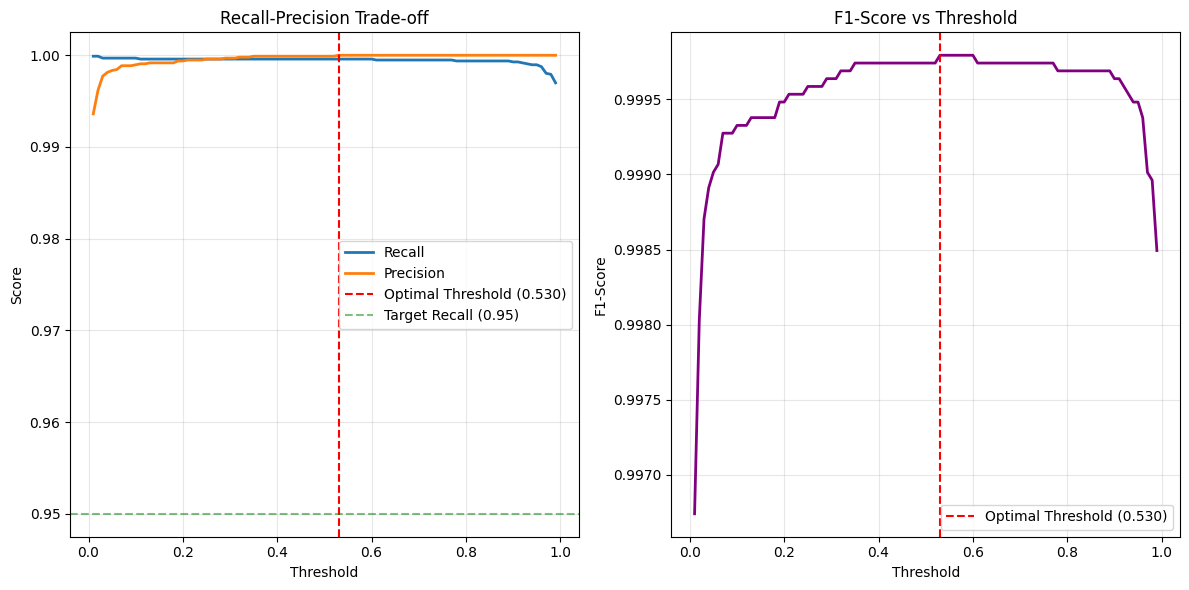

In [32]:
# Plot Recall-Precision trade-off vs Threshold
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(thresholds, recalls, label='Recall', linewidth=2)
plt.plot(thresholds, precisions, label='Precision', linewidth=2)
plt.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.3f})')
plt.axhline(y=target_recall, color='green', linestyle='--', alpha=0.5, label=f'Target Recall ({target_recall})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Recall-Precision Trade-off')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(thresholds, f1_scores, linewidth=2, color='purple')
plt.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.3f})')
plt.xlabel('Threshold')
plt.ylabel('F1-Score')
plt.title('F1-Score vs Threshold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 10: Visualizations

### Confusion Matrix

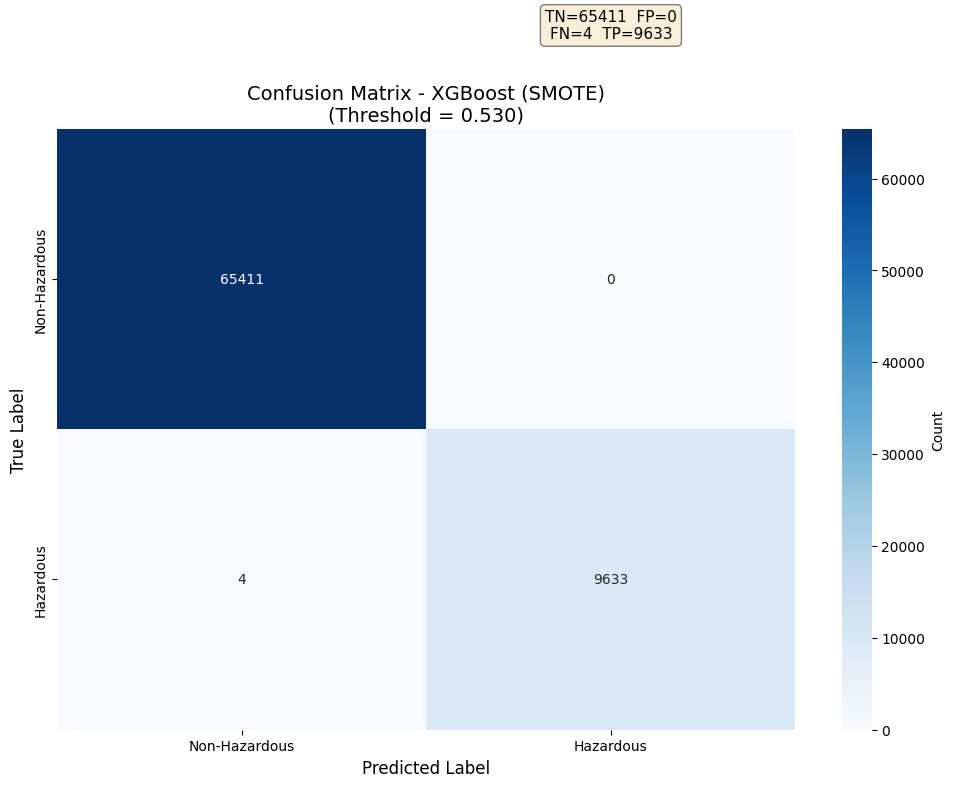


Confusion Matrix Breakdown:
True Negatives (TN):  65411
False Positives (FP): 0
False Negatives (FN): 4
True Positives (TP):  9633

Missed hazardous asteroids (FN): 4 out of 9637 (0.04%)


In [33]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_optimal)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Hazardous', 'Hazardous'],
            yticklabels=['Non-Hazardous', 'Hazardous'],
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_model_name}\n(Threshold = {optimal_threshold:.3f})', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)

# Add text annotations
tn, fp, fn, tp = cm.ravel()
plt.text(1.5, -0.3, f'TN={tn}  FP={fp}\nFN={fn}  TP={tp}', 
         fontsize=11, ha='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Calculate metrics from confusion matrix
print("\nConfusion Matrix Breakdown:")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")
print(f"\nMissed hazardous asteroids (FN): {fn} out of {fn + tp} ({fn/(fn+tp)*100:.2f}%)")

### ROC Curve

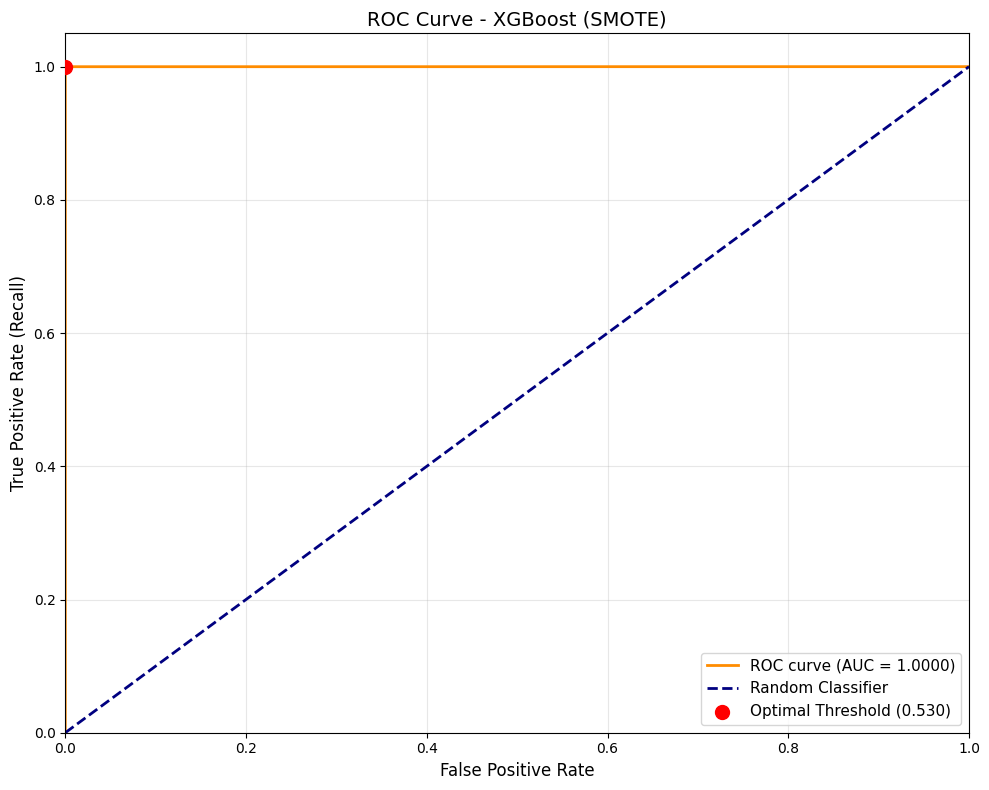

In [34]:
# ROC Curve
fpr, tpr, roc_thresholds = roc_curve(y_test, best_proba)
roc_auc = roc_auc_score(y_test, best_proba)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

# Mark optimal threshold point
optimal_idx = np.argmin(np.abs(roc_thresholds - optimal_threshold))
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100, 
            label=f'Optimal Threshold ({optimal_threshold:.3f})', zorder=5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title(f'ROC Curve - {best_model_name}', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Feature Importance

Top 15 Most Important Features:
                        feature  importance
1            Est Dia in KM(min)    0.417020
3             Est Dia in M(min)    0.281355
17   Minimum Orbit Intersection    0.194086
4             Est Dia in M(max)    0.053337
0            Absolute Magnitude    0.013270
5         Est Dia in Miles(min)    0.012790
25          Perihelion Distance    0.004932
18  Jupiter Tisserand Invariant    0.003895
11               Miles per hour    0.003259
22                  Inclination    0.002281
12     Miss Dist.(Astronomical)    0.002210
20                 Eccentricity    0.001878
23           Asc Node Longitude    0.001427
26               Perihelion Arg    0.001377
27                Aphelion Dist    0.001127


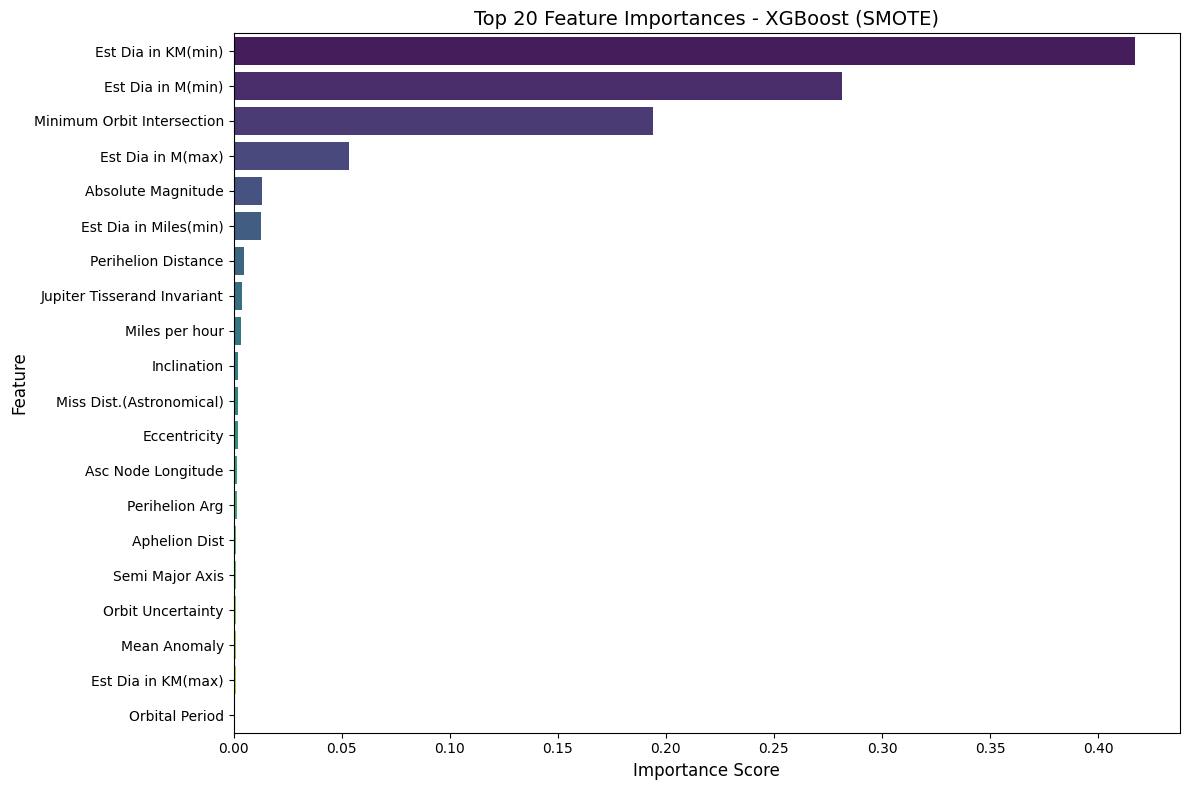

In [35]:
# Feature Importance
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("Top 15 Most Important Features:")
    print(feature_importance.head(15))
    
    # Plot feature importance
    plt.figure(figsize=(12, 8))
    top_n = min(20, len(feature_importance))
    sns.barplot(data=feature_importance.head(top_n), x='importance', y='feature', palette='viridis')
    plt.title(f'Top {top_n} Feature Importances - {best_model_name}', fontsize=14)
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance not available for this model.")

## Summary and Conclusions

In [36]:
# Final Summary
print("=" * 70)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 70)
print(f"\nBest Model: {best_model_name}")
print(f"Optimal Probability Threshold: {optimal_threshold:.4f}")
print(f"\nTest Set Metrics:")
print(f"  ROC-AUC Score:     {roc_auc_score(y_test, best_proba):.4f}")
print(f"  Recall (Hazard):   {recall_score(y_test, y_pred_optimal):.4f}")
print(f"  Precision (Hazard): {precision_score(y_test, y_pred_optimal):.4f}")
print(f"  F1-Score (Hazard):  {f1_score(y_test, y_pred_optimal):.4f}")
print(f"  Accuracy:          {(y_test == y_pred_optimal).mean():.4f}")
print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {tn:,}")
print(f"  False Positives: {fp:,}")
print(f"  False Negatives: {fn:,}")
print(f"  True Positives:  {tp:,}")
print(f"\nKey Achievement: {'✓' if recall_score(y_test, y_pred_optimal) >= 0.95 else '✗'} Recall ≥ 95%")
print("=" * 70)

FINAL MODEL PERFORMANCE SUMMARY

Best Model: XGBoost (SMOTE)
Optimal Probability Threshold: 0.5300

Test Set Metrics:
  ROC-AUC Score:     1.0000
  Recall (Hazard):   0.9996
  Precision (Hazard): 1.0000
  F1-Score (Hazard):  0.9998
  Accuracy:          0.9999

Confusion Matrix:
  True Negatives:  65,411
  False Positives: 0
  False Negatives: 4
  True Positives:  9,633

Key Achievement: ✓ Recall ≥ 95%


## Model Persistence

In [37]:
# Save the best model and preprocessing objects
import joblib

# Save model
joblib.dump(best_model, 'best_asteroid_hazard_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
joblib.dump(imputer, 'feature_imputer.pkl')

# Save optimal threshold and feature names
model_metadata = {
    'optimal_threshold': optimal_threshold,
    'feature_names': X_train.columns.tolist(),
    'log_transform_cols': log_transform_cols,
    'model_name': best_model_name,
    'roc_auc': roc_auc_score(y_test, best_proba),
    'recall': recall_score(y_test, y_pred_optimal),
    'precision': precision_score(y_test, y_pred_optimal)
}
joblib.dump(model_metadata, 'model_metadata.pkl')

print("Model and preprocessing objects saved successfully!")
print(f"  - best_asteroid_hazard_model.pkl")
print(f"  - feature_scaler.pkl")
print(f"  - feature_imputer.pkl")
print(f"  - model_metadata.pkl")

Model and preprocessing objects saved successfully!
  - best_asteroid_hazard_model.pkl
  - feature_scaler.pkl
  - feature_imputer.pkl
  - model_metadata.pkl
